In [1]:
# importing libraries needed for this project
import pandas as pd       # for loading and working with data
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt  # for charts
import seaborn as sns     # for better looking charts

In [2]:
# reading the csv file and storing it as a dataframe
# dataframe is like an excel table with rows and columns
df = pd.read_csv(r'C:\Users\Ar\Desktop\stroke_prediction\data\heart.csv')
print(df)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [3]:
# looking at first 5 rows to understand the data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# checking column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# checking basic statistics like min, max, mean for each column
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# checking if any column has missing values
# isnull() returns True where value is missing
# sum() counts the True values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [7]:
# cholesterol and blood pressure cannot be 0 in a living person
# so these zeros are hidden missing values
chol_zeros = (df['Cholesterol'] == 0).sum()
bp_zeros = (df['RestingBP'] == 0).sum()
print("cholesterol zeros:", chol_zeros)
print("restingbp zeros:", bp_zeros)

cholesterol zeros: 172
restingbp zeros: 1


In [8]:
# checking how many patients have heart disease vs not
# 0 = no heart disease, 1 = has heart disease
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True) * 100)

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


C:\Users\Ar\AppData\Local\Temp\ipykernel_14600\397026157.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette=['#1D9E75', '#D85A30'])
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


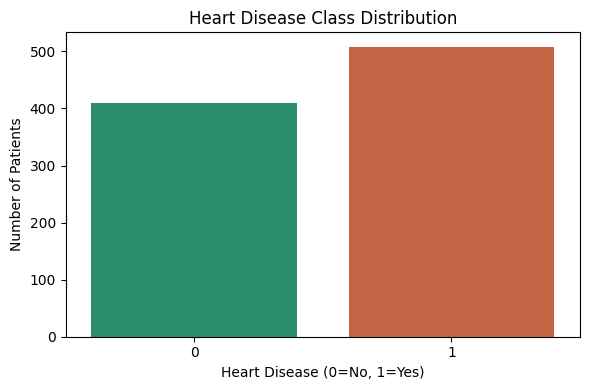

In [9]:
# bar chart to visualize class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df, palette=['#1D9E75', '#D85A30'])
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [10]:
# models only understand numbers not text
# get_dummies converts text columns into 0/1 numeric columns
# drop_first=True removes one column per group to avoid duplicate information
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType',
                                          'RestingECG', 'ExerciseAngina',
                                          'ST_Slope'], drop_first=True)
print("shape before encoding:", df.shape)
print("shape after encoding:", df_encoded.shape)
print("columns:", list(df_encoded.columns))

shape before encoding: (918, 12)
shape after encoding: (918, 16)
columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [11]:
# X contains all input columns the model will learn from
# y contains only the target column we want to predict
# drop() removes HeartDisease from inputs so model doesnt cheat
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 15)
y shape: (918,)


In [12]:
from sklearn.model_selection import train_test_split

# splitting data into 80% for training and 20% for testing
# model learns from training set and gets evaluated on test set
# stratify=y makes sure both sets have same ratio of 0s and 1s
# random_state=42 gives same split every time we run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("training samples:", X_train.shape[0])
print("testing samples:", X_test.shape[0])
print("training class balance:")
print(y_train.value_counts())

training samples: 734
testing samples: 184
training class balance:
HeartDisease
1    406
0    328
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler

# scaling converts all numbers to same range
# without scaling model thinks higher numbers are more important
# for example age=54 vs cholesterol=223, model would favor cholesterol unfairly
# we fit scaler on training data only
# if we fit on test data too, model would have seen test data during training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("scaling done")

scaling done


In [14]:
from imblearn.over_sampling import SMOTE

# our classes are not perfectly balanced (406 vs 328)
# SMOTE creates new synthetic patient records for minority class
# it does not copy existing records, it creates new ones by interpolation
# applied only on training data, test data must stay real and untouched
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("before SMOTE:", y_train.value_counts().to_dict())
print("after SMOTE:", y_train_smote.value_counts().to_dict())

before SMOTE: {1: 406, 0: 328}
after SMOTE: {1: 406, 0: 406}


In [15]:
from sklearn.linear_model import LinearRegression

# linear regression normally predicts continuous numbers
# we use it here for classification by applying a 0.5 threshold
# values >= 0.5 are predicted as stroke risk (1)
# values < 0.5 are predicted as no stroke risk (0)
model = LinearRegression()
model.fit(X_train_smote, y_train_smote)
print("model trained")

model trained


In [16]:
# model gives raw continuous numbers like 0.3, 0.7, 1.1
# we convert them to 0 or 1 using 0.5 as the cutoff
# note: linear regression can go below 0 or above 1 unlike logistic regression
y_pred_raw = model.predict(X_test_scaled)
y_pred = (y_pred_raw >= 0.5).astype(int)

print("raw predictions:", y_pred_raw[:10].round(2))
print("binary predictions:", y_pred[:10])
print("actual values:", y_test.values[:10])

raw predictions: [ 1.07  0.18  0.96  0.54  0.3   0.38 -0.09  0.68 -0.08  1.03]
binary predictions: [1 0 1 1 0 0 0 1 0 1]
actual values: [1 1 1 1 0 0 0 1 0 1]


In [22]:
import joblib

# saving model and scaler so streamlit app can load them directly
# without saving, app would need to retrain model every time it runs
joblib.dump(model, r'C:\Users\Ar\Desktop\stroke_prediction\model.pkl')
joblib.dump(scaler, r'C:\Users\Ar\Desktop\stroke_prediction\scaler.pkl')
print("model saved")
print("scaler saved")

model saved
scaler saved


In [18]:
from sklearn.metrics import confusion_matrix

# confusion matrix shows 4 types of predictions:
# true negative  = correctly said no disease
# false positive = said disease but patient was healthy
# false negative = said no disease but patient actually has it (most dangerous)
# true positive  = correctly said disease
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print("true negative:", tn)
print("false positive:", fp)
print("false negative:", fn)
print("true positive:", tp)

confusion matrix:
[[71 11]
 [ 7 95]]
true negative: 71
false positive: 11
false negative: 7
true positive: 95


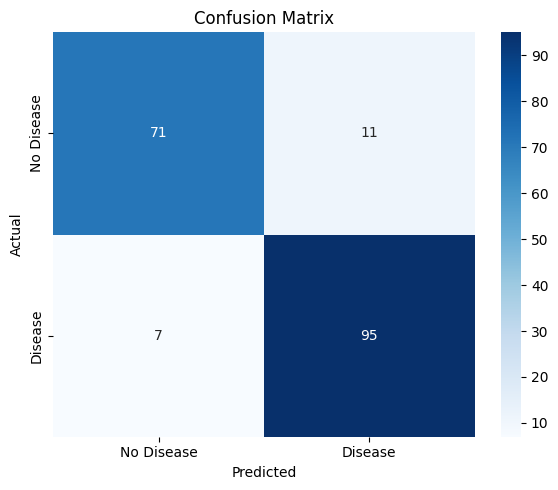

In [19]:
# heatmap makes confusion matrix easier to read visually
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# accuracy = how many predictions were correct overall
# precision = when i say disease, how often am i right
# recall = out of all actual disease cases, how many did i catch
# recall matters most here because missing a real case is dangerous
# f1 = balance between precision and recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", round(accuracy * 100, 2), "%")
print("precision:", round(precision * 100, 2), "%")
print("recall:", round(recall * 100, 2), "%")
print("f1 score:", round(f1 * 100, 2), "%")

accuracy: 90.22 %
precision: 89.62 %
recall: 93.14 %
f1 score: 91.35 %


AUC score: 0.926


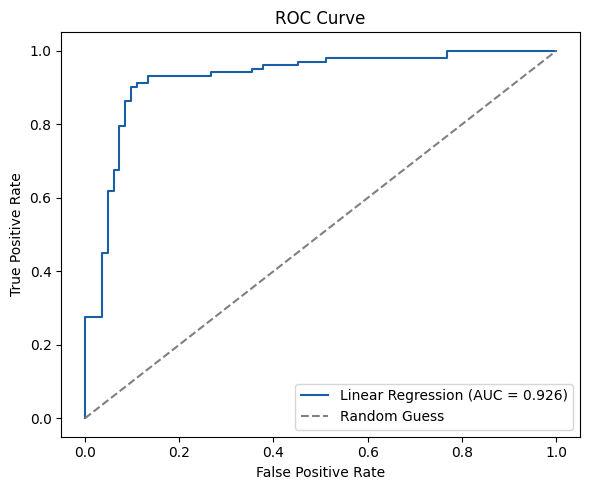

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve shows how well model separates disease from no disease
# AUC of 0.5 means random guessing, AUC of 1.0 means perfect
# higher AUC is better
fpr, tpr, thresholds = roc_curve(y_test, y_pred_raw)
auc_score = roc_auc_score(y_test, y_pred_raw)

print("AUC score:", round(auc_score, 3))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#185FA5',
         label='Linear Regression (AUC = ' + str(round(auc_score, 3)) + ')')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Strengths and Limitations of Linear Regression for Classification

### Strengths
- Simple and fast to train
- Easy to interpret, coefficients show which features affect prediction
- Works reasonably well when classes are fairly separable

### Limitations
- Predicts values outside 0 and 1 range (we saw values like -0.04 and 1.06)
- Not designed for binary classification problems
- Logistic Regression would be more appropriate for this task
- Sensitive to outliers which can affect the predictions